In [ ]:
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

In [ ]:
url = 'https://raw.githubusercontent.com/LucasOF23/AM/refs/heads/main/global_cancer_patients_2015_2024.csv'

# Criando as Classes principais
Primeiramente incorporamos as classes `Encoder`, `Modelo` e `Dados`.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

Abaixo temos a classe `Encoder`, o método mapping apenas faz um mapeamento de atributos categóricos para inteiros consecutivos, já o método encoding faz o uso dos métodos OneHotEncoder e OrdinalEncoder da sklearn.

In [ ]:
# Classe Encoder

class Encoder:
    """
    Classe utilitária para codificação de atributos categóricos (OneHot ou Ordinal).
    """

    @staticmethod
    def mapping(df):
        df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

        country_mapping = {
            'Australia': 0, 'Brazil': 1, 'Canada': 2, 'China': 3, 'Germany': 4,
            'India': 5, 'Pakistan': 6, 'Russia': 7, 'UK': 8, 'USA': 9
        }
        df['Country_Region'] = df['Country_Region'].map(country_mapping)

        year_mapping = {year: idx for idx, year in enumerate(range(2015, 2025))}
        df['Year'] = df['Year'].map(year_mapping)

        stage_mapping = {
            "Stage 0": 0, "Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4
        }
        df['Cancer_Stage'] = df['Cancer_Stage'].map(stage_mapping)

        type_mapping = {
            'Breast': 0, 'Cervical': 1, 'Colon': 2, 'Leukemia': 3,
            'Liver': 4, 'Lung': 5, 'Prostate': 6, 'Skin': 7
        }
        df['Cancer_Type'] = df['Cancer_Type'].map(type_mapping)

        return df

    @staticmethod
    def encoding(df, only_ordinal=False):
        if not only_ordinal:
            for col in ['Gender', 'Country_Region', 'Cancer_Type']:
                encoder = OneHotEncoder(sparse_output=False)
                encoded = encoder.fit_transform(df[[col]])
                col_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([col]))
                df.drop(columns=[col], inplace=True)
                df = pd.concat([df.reset_index(drop=True), col_df], axis=1)
        else:
            Encoder.mapping(df)

        df['Year'] = OrdinalEncoder(categories=[[i for i in range(2015, 2025)]]).fit_transform(df[['Year']])
        stages = [["Stage 0", "Stage I", "Stage II", "Stage III", "Stage IV"]]
        df['Cancer_Stage'] = OrdinalEncoder(categories=stages).fit_transform(df[['Cancer_Stage']])

        return df


Abaixo temos a classe `Modelo` para realizar os treinamento de módelos com o conjunto de dados e definição de hiperparametros em cada caso.

In [ ]:
# Classe Modelo

class Modelo:
    """
    Classe para treinar, avaliar e ajustar modelos de regressão (MLP, SVR ou DTR),
    utilizando validação cruzada com suporte à codificação e normalização dos dados.
    """

    def __init__(self, nome_arq=None, encoding=False, only_ordinal=False):
        """
        Inicializa o objeto carregando e codificando o dataset.

        Parâmetros:
        - nome_arq (str): Caminho para o arquivo CSV contendo os dados.
        - encoding (bool): Se True, aplica codificação OneHot; caso contrário, aplica mapeamento ordinal.
        - only_ordinal (bool): Se True, aplica apenas codificação ordinal mesmo com encoding=True.
        """

        if(nome_arq == None):
          self.df = pd.read_csv(url)
        else:
          self.df = pd.read_csv(nome_arq)
        self.df.drop(columns=['Patient_ID'], inplace=True)

        # Aplicação da codificação escolhida
        if encoding:
            self.df = Encoder.encoding(self.df, only_ordinal)
        else:
            self.df = Encoder.mapping(self.df)

    def treinar_modelo(self, nome_modelo, prediction_value='Target_Severity_Score',
                       take_out_values=False):
        """
        Realiza treinamento e avaliação com validação cruzada 5-fold.

        Parâmetros:
        - nome_modelo (str): Nome do modelo ('MLP', 'SVR' ou 'DTR').
        - prediction_value (str): Nome da variável alvo.
        - take_out_values (bool): Se True, remove variáveis auxiliares do conjunto de entrada.
        """
        # Seleção de atributos
        drop_cols = ["Treatment_Cost_USD", "Survival_Years", "Target_Severity_Score"] \
                    if take_out_values else [prediction_value]
        X = self.df.drop(columns=drop_cols)
        y = self.df[prediction_value]

        # Validação cruzada 5-fold
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        mse_scores, r2_scores = [], []
        self.mse_score = float('inf')  # Armazena o menor erro MSE observado

        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Escalonamento dos dados
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # Instancia o modelo com hiperparâmetros padrão
            model = self._get_model(nome_modelo)

            # Treinamento e avaliação
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            # Métricas
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            mse_scores.append(mse)
            r2_scores.append(r2)

            # Guarda o melhor modelo
            if mse < self.mse_score:
                self.model = model
                self.scaler = scaler
                self.mse_score = mse

        # Exibe as métricas
        print("MSE por fold:", mse_scores)
        print("MSE médio:", np.mean(mse_scores))
        print("R² por fold:", r2_scores)
        print("R² médio:", np.mean(r2_scores))

    def _get_model(self, nome_modelo):
        """
        Retorna uma instância do modelo com hiperparâmetros definidos.

        Parâmetros:
        - nome_modelo (str): 'MLP', 'SVR' ou 'DTR'.
        """
        if nome_modelo == "MLP":
            return MLPRegressor(hidden_layer_sizes=(100, ), activation='identity',
                                max_iter=1000, random_state=42, alpha=0.001,
                                learning_rate_init=0.001)
        elif nome_modelo == "SVR":
            return SVR(kernel='linear', C=0.1, epsilon=0.01)
        elif nome_modelo == "DTR":
            return DecisionTreeRegressor(criterion='friedman_mse', max_depth=None,
                                         min_samples_leaf=4, min_samples_split=2,
                                         random_state=42)
        else:
            raise ValueError("Modelo inválido. Use: 'MLP', 'SVR' ou 'DTR'.")

    def definir_hiperparametros(self, nome_modelo, prediction_value='Target_Severity_Score',
                                take_out_values=False):
        """
        Realiza ajuste fino dos hiperparâmetros usando GridSearchCV.

        Parâmetros:
        - nome_modelo (str): Tipo do modelo ('MLP', 'SVR', 'DTR').
        - prediction_value (str): Coluna alvo da regressão.
        - take_out_values (bool): Se True, remove colunas auxiliares do conjunto de entrada.
        """
        # Preparação dos dados
        drop_cols = ["Treatment_Cost_USD", "Survival_Years", "Target_Severity_Score"] \
                    if take_out_values else [prediction_value]
        X = self.df.drop(columns=drop_cols)
        y = self.df[prediction_value]

        # Verifica se o modelo precisa de normalização
        scale_needed = nome_modelo in ["MLP", "SVR"]

        # Define modelo e parâmetros de busca
        if nome_modelo == "MLP":
            model = MLPRegressor(max_iter=1000, random_state=42)
            param_grid = {
                'model__hidden_layer_sizes': [(100,), (100, 50), (200, 100)],
                'model__activation': ['relu', 'identity'],
                'model__alpha': [1e-4, 1e-3],
                'model__learning_rate_init': [0.001, 0.01]
            }
        elif nome_modelo == "SVR":
            model = SVR()
            param_grid = {
                'model__kernel': ['rbf', 'linear'],
                'model__C': [0.1, 1, 10],
                'model__epsilon': [0.01, 0.1]
            }
        elif nome_modelo == "DTR":
            model = DecisionTreeRegressor(random_state=42)
            param_grid = {
                'model__max_depth': [3, 5, 10, None],
                'model__min_samples_split': [2, 5, 10],
                'model__min_samples_leaf': [1, 2, 4],
                'model__criterion': ['squared_error', 'friedman_mse']
            }
        else:
            raise ValueError("Modelo inválido. Use: 'MLP', 'SVR' ou 'DTR'.")

        # Pipeline com ou sem normalização
        steps = [('scaler', StandardScaler())] if scale_needed else []
        steps.append(('model', model))
        pipeline = Pipeline(steps)

        # Busca em grade
        grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', verbose=2, n_jobs=-1)
        grid.fit(X, y)

        print("Melhor R²:", grid.best_score_)
        print("Melhores hiperparâmetros:", grid.best_params_)

    def predicao(self, dado):
        """
        Realiza uma predição com o modelo treinado.

        Parâmetros:
        - dado (list): Lista com os atributos de entrada (já na ordem e escala correta).
        """
        dado = np.array(dado).reshape(1, -1)
        dado_escalado = self.scaler.transform(dado)
        pred = self.model.predict(dado_escalado)
        print("Predição:", pred)


Abaixo temos a classe `Dados` com métodos que nos possibilitam analisar o conjunto de dados que temos.

In [ ]:
# Classe Dados

class Dados:
    """
    Classe para carregar, explorar e codificar um conjunto de dados sobre pacientes com câncer.
    """

    def __init__(self, nome_arq=None):
        """
        Inicializa a classe lendo o CSV e removendo a coluna de ID.

        Parâmetros:
        - nome_arq (str): Caminho para o arquivo CSV.
        """
        if(nome_arq == None):
          self.df = pd.read_csv(url)
        else:
          self.df = pd.read_csv(nome_arq)
        self.df.drop(columns=['Patient_ID'], inplace=True)
        self.already_encoded = False

    def distribuicao(self):
        """
        Exibe a distribuição de cada atributo do dataset.
        Usa gráfico de barras para atributos categóricos e histograma para numéricos.
        """
        for col in self.df.columns:
            plt.figure(figsize=(8, 4))

            if self.df[col].dtype == 'object' or self.df[col].nunique() < 20:
                self.df[col].value_counts().sort_index().plot(kind='bar')
                plt.xlabel("Valor")
            else:
                self.df[col].plot(kind='hist', bins=20, edgecolor='black')
                plt.xlabel("Intervalo de valores")

            plt.title(f"Distribuição - {col}")
            plt.ylabel("Frequência")
            plt.tight_layout()
            plt.show()

    def correlacao(self, encoding=False):
        """
        Exibe a matriz de correlação entre variáveis numéricas do dataset.

        Parâmetros:
        - encoding (bool): Se True, aplica codificação OneHot; senão, mapeamento ordinal.
        """
        if not self.already_encoded:
            if encoding:
                self.df = Encoder.encoding(self.df)
            else:
                self.df = Encoder.mapping(self.df)
            self.already_encoded = True

        corr_matrix = self.df.corr()
        print(corr_matrix)

        plt.figure(figsize=(12, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Matriz de Correlação')
        plt.tight_layout()
        plt.show()

    def correlacao_par(self, first_feature, second_feature, encoding=False):
        """
        Cria uma nova feature como interação entre duas colunas e exibe a matriz de correlação.

        Parâmetros:
        - first_feature (str): Primeira coluna.
        - second_feature (str): Segunda coluna.
        - encoding (bool): Se True, aplica codificação OneHot; senão, mapeamento ordinal.
        """
        if not self.already_encoded:
            if encoding:
                self.df = Encoder.encoding(self.df)
            else:
                self.df = Encoder.mapping(self.df)
            self.already_encoded = True

        self.df['New_Feature'] = self.df[first_feature] * self.df[second_feature]
        corr_matrix = self.df.corr()
        print(corr_matrix)

        plt.figure(figsize=(12, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Matriz de Correlação com Interação')
        plt.tight_layout()
        plt.show()

    def info(self):
        """
        Exibe informações básicas e estatísticas descritivas do dataset.
        """
        print("INFO:")
        self.df.info()
        print("\nDESCRIBE:")
        print(self.df.describe())

# Trabalho Aprendizado de Máquina

# Introdução

Esse é o trabalho 1 da disciplina de aprendizado de máquina. Para nosso trabalho buscamos utilizar alguns métodos de aprendizado de máquina supervisionado para uma tarefa de regressão sobre um conjunto de dados de pacientes com câncer. O conjunto de dados tirado do kaggle se chama "global-cancer-patients-2015-2024" e contém, além de diversas informações acerca de pacientes com câncer (como idade, país, tipo de cancer, fatores de risco como obesidade, etc), uma coluna chamada "Target_Severity_Score" (Valor de Severidade Alvo) que indica a severidade do caso daquele paciente, e é isso que tentaremos predizer. Para isso estaremos testando alguns métodos sendo eles Redes Neurais, Máquinas de Vetores de Suporte e Árvores de Decisão.

# Dados

Antes de começarmos a testar os modelos podemos usar algumas funções para obter informações acerca de nosso conjunto de dados.

## Informações Principais

Abaixo usaremos o método info() da classe dados para obter algumas das informações principais do conjunto de dados. Primeiramente podemos conferir os nomes de todos os 13 atributos da base de dados e a quantidade de objetos não nulos em cada, como se pode ver não há atributos nulos indicando que a base de dados é completa. Por fim, podemos conferir em cada atributo informações como média dos valores, valor mínimo e valor máximo.

In [ ]:
dados = Dados()
dados.info()

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Country_Region         50000 non-null  object 
 3   Year                   50000 non-null  int64  
 4   Genetic_Risk           50000 non-null  float64
 5   Air_Pollution          50000 non-null  float64
 6   Alcohol_Use            50000 non-null  float64
 7   Smoking                50000 non-null  float64
 8   Obesity_Level          50000 non-null  float64
 9   Cancer_Type            50000 non-null  object 
 10  Cancer_Stage           50000 non-null  object 
 11  Treatment_Cost_USD     50000 non-null  float64
 12  Survival_Years         50000 non-null  float64
 13  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage:

## Distribuição

Com o método distribuicao() podemos visualizar gráficos representando a distribuição dos atributos, ou seja, a quantidade de objetos com determinado valor de atributo ou em determinado intervalo de valores. Esse tipo de informação é importante para sabermos se algum tipo de valor de atributo é mais frequente que outros (!!!). Como podemos observar, com exceção do atributo alvo de "Severidade" que possui uma distribuição normal, os outros possuem uma distribuição em sua maioria constante.

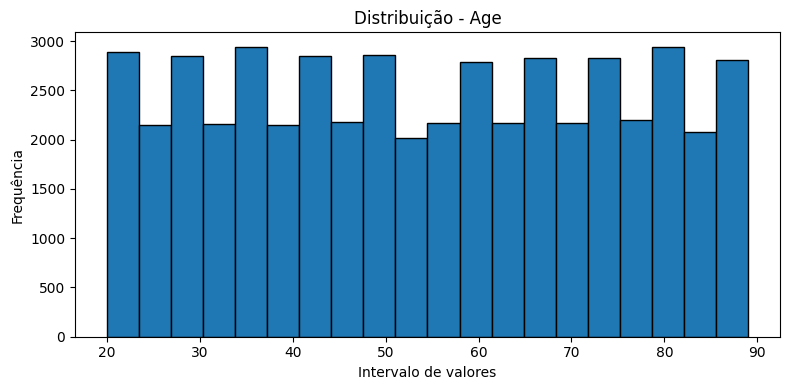

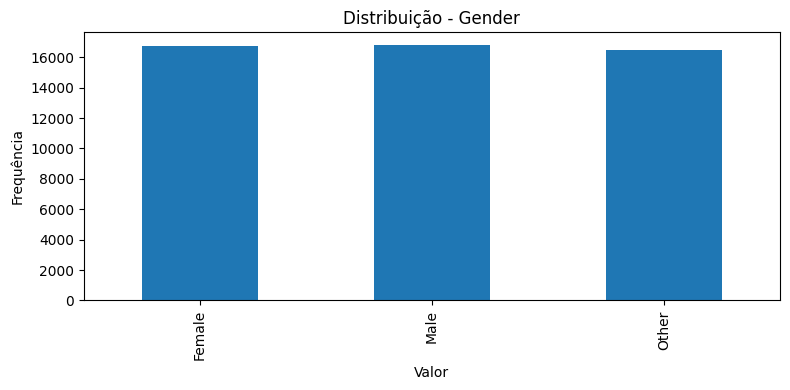

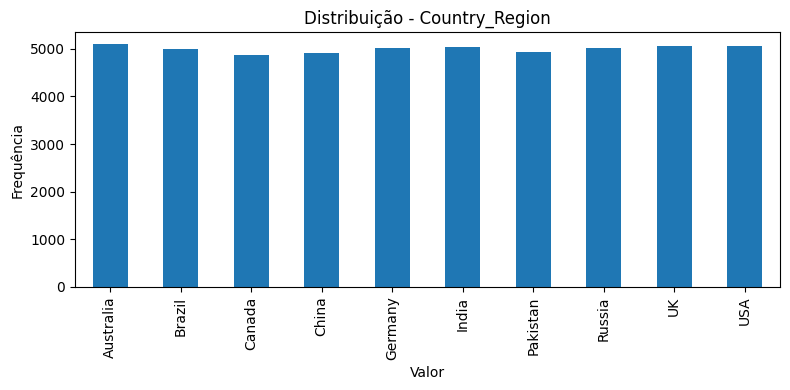

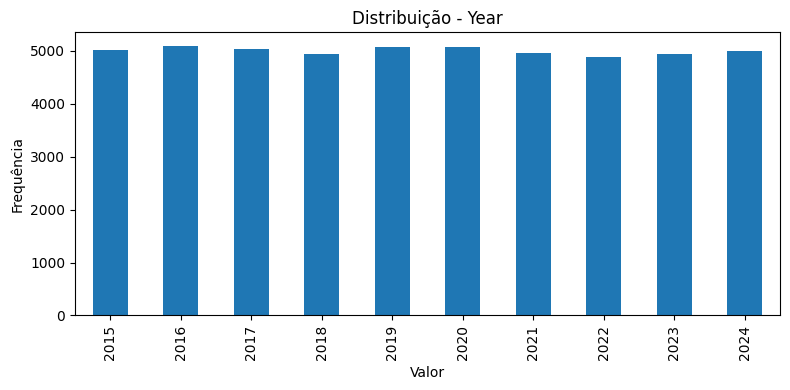

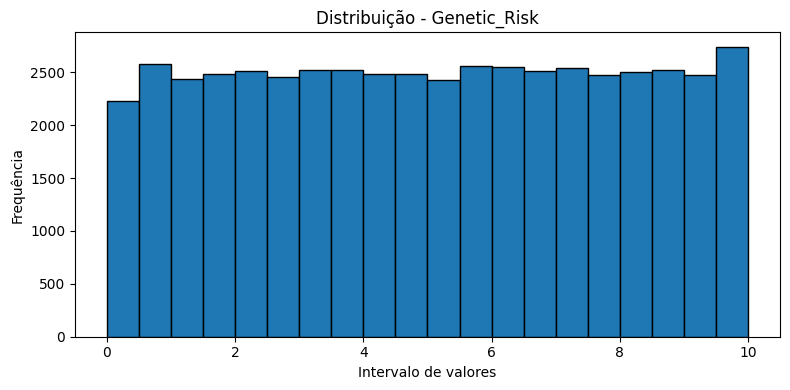

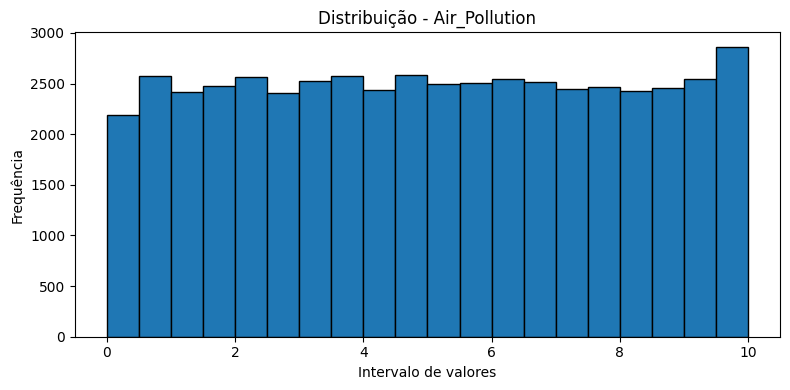

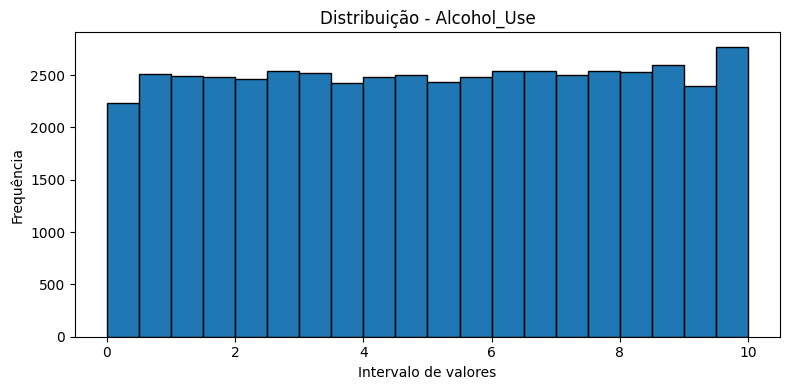

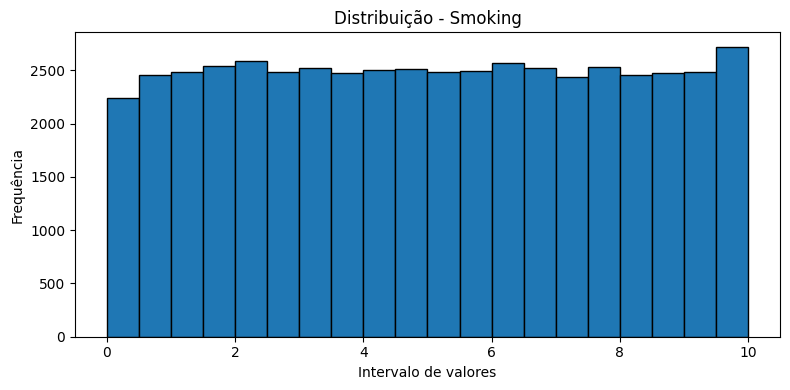

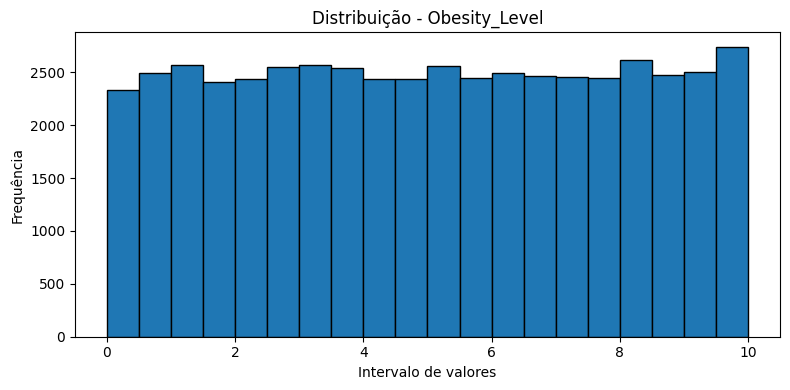

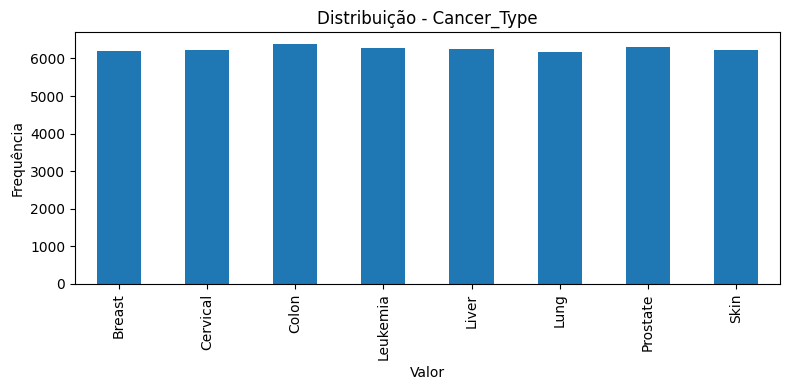

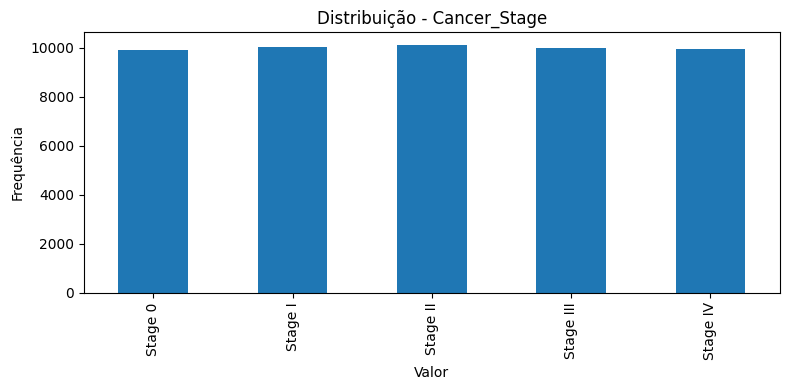

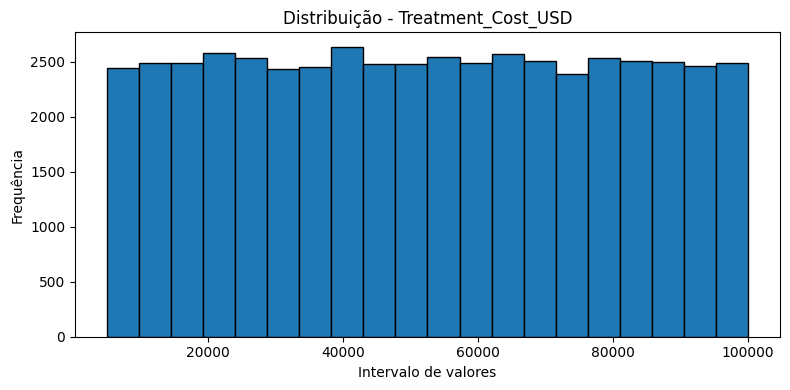

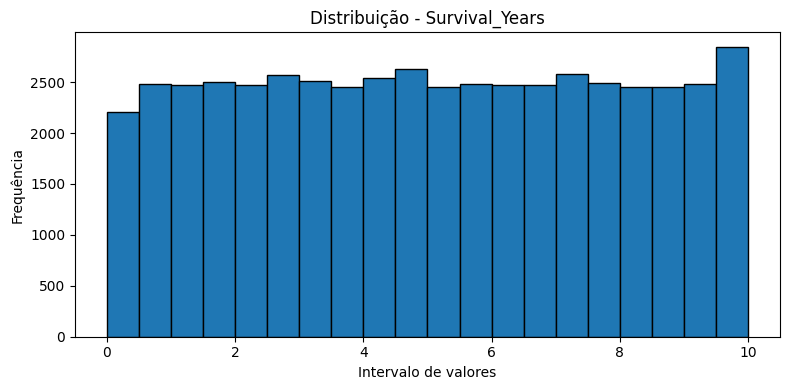

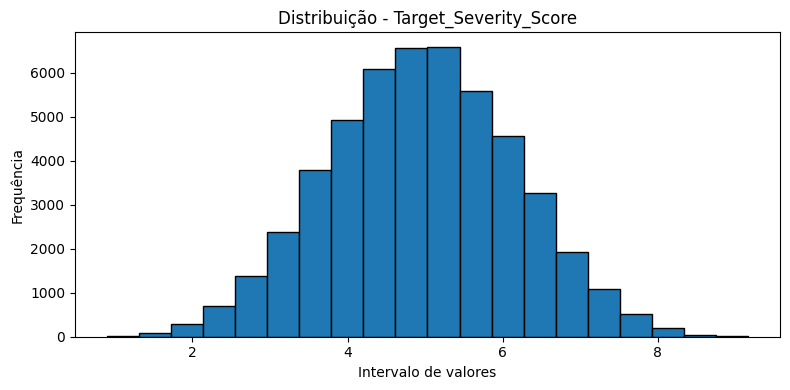

In [ ]:
dados.distribuicao()

## Correlações

O método correlacao() é muito importante para conferirmos quais atributos possuem uma influencia direta em outros, oque ajuda a identificar atributos mais importantes e atributos redundantes. É valido ressaltar que não necessariamente um atributo que não é ressaltado é desnecessário. Como podemos ver abaixo percebemos que o atributo alvo de "Severidade" é impactado principalmente pelos valores de fator de risco, sendo eles "Risco Genético", "Poluição do Ar", "Consumo de Bebidas Álcoolicas", "Fumantes" e "Nivel de Obesidade", além do atributo custo de tratamento. Vale ressaltar que a relação dos fatores de risco com o atributo alvo é proporcional, ou seja quando um aumenta o outro também aumenta, enquanto que a relação com o custo de tratamento é inversamente proporcional, quando um aumenta o outro diminui.

                            Age    Gender  Country_Region      Year  \
Age                    1.000000  0.000866        0.008048 -0.002505   
Gender                 0.000866  1.000000        0.003745 -0.003964   
Country_Region         0.008048  0.003745        1.000000  0.002639   
Year                  -0.002505 -0.003964        0.002639  1.000000   
Genetic_Risk           0.002229  0.001788        0.000919  0.009942   
Air_Pollution          0.001101 -0.003600       -0.002643  0.000649   
Alcohol_Use           -0.004130  0.004085        0.004876  0.001934   
Smoking                0.001734  0.001722        0.005443 -0.006209   
Obesity_Level         -0.002706  0.002059        0.001076 -0.002441   
Cancer_Type           -0.001803 -0.005456       -0.000559 -0.000409   
Cancer_Stage          -0.003309 -0.003681        0.000923 -0.011968   
Treatment_Cost_USD     0.003591  0.002705       -0.003682  0.000061   
Survival_Years        -0.000147 -0.002696        0.005121  0.000018   
Target

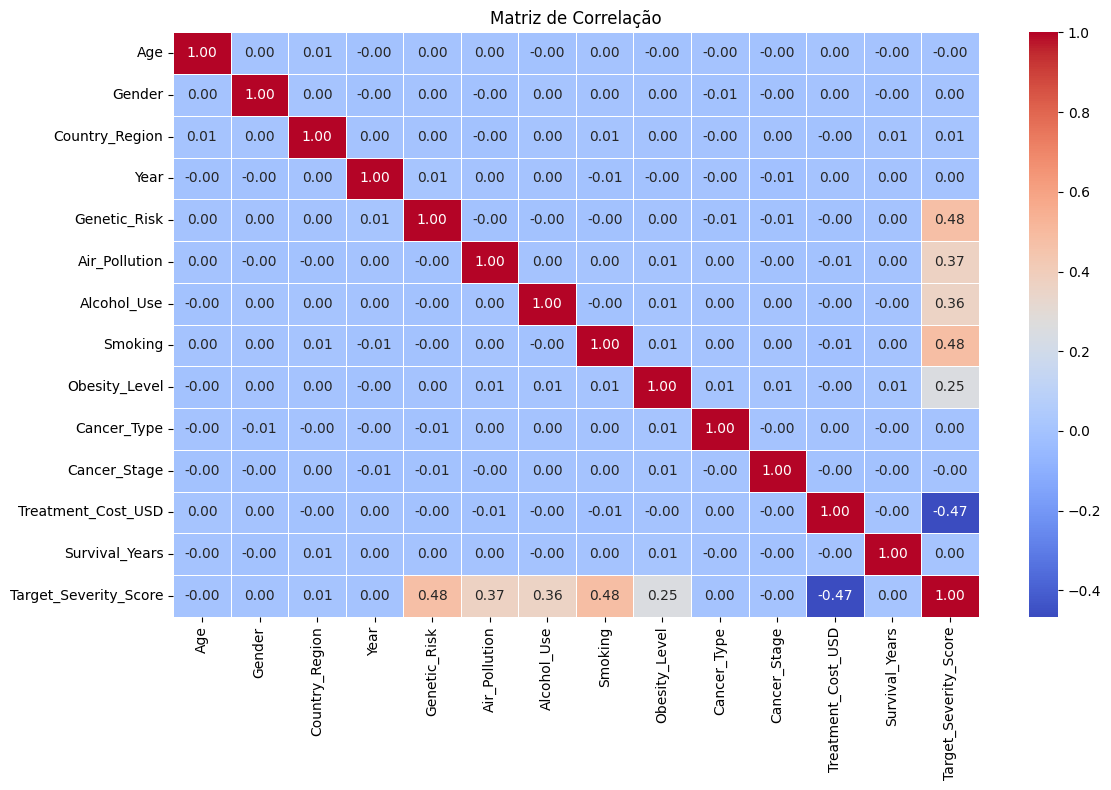

In [ ]:
dados.correlacao()

Abaixo nós utilizamos o método correlacao_par(), para testar se caso ao combinar 2 atributos alguma correlaçao antes não visivel é ressaltada. Utilizamos principalmente para checar se ao juntar Cancer_Type (Tipo de Câncer) com Cancer_Stage (Estágio de Câncer) obtiamos algum nível de correlação. Não conseguimos observar essa correlação que talvez seja uma relação mais difícil de perceber ou não exista.

                            Age    Gender  Country_Region      Year  \
Age                    1.000000  0.000866        0.008048 -0.002505   
Gender                 0.000866  1.000000        0.003745 -0.003964   
Country_Region         0.008048  0.003745        1.000000  0.002639   
Year                  -0.002505 -0.003964        0.002639  1.000000   
Genetic_Risk           0.002229  0.001788        0.000919  0.009942   
Air_Pollution          0.001101 -0.003600       -0.002643  0.000649   
Alcohol_Use           -0.004130  0.004085        0.004876  0.001934   
Smoking                0.001734  0.001722        0.005443 -0.006209   
Obesity_Level         -0.002706  0.002059        0.001076 -0.002441   
Cancer_Type           -0.001803 -0.005456       -0.000559 -0.000409   
Cancer_Stage          -0.003309 -0.003681        0.000923 -0.011968   
Treatment_Cost_USD     0.003591  0.002705       -0.003682  0.000061   
Survival_Years        -0.000147 -0.002696        0.005121  0.000018   
Target

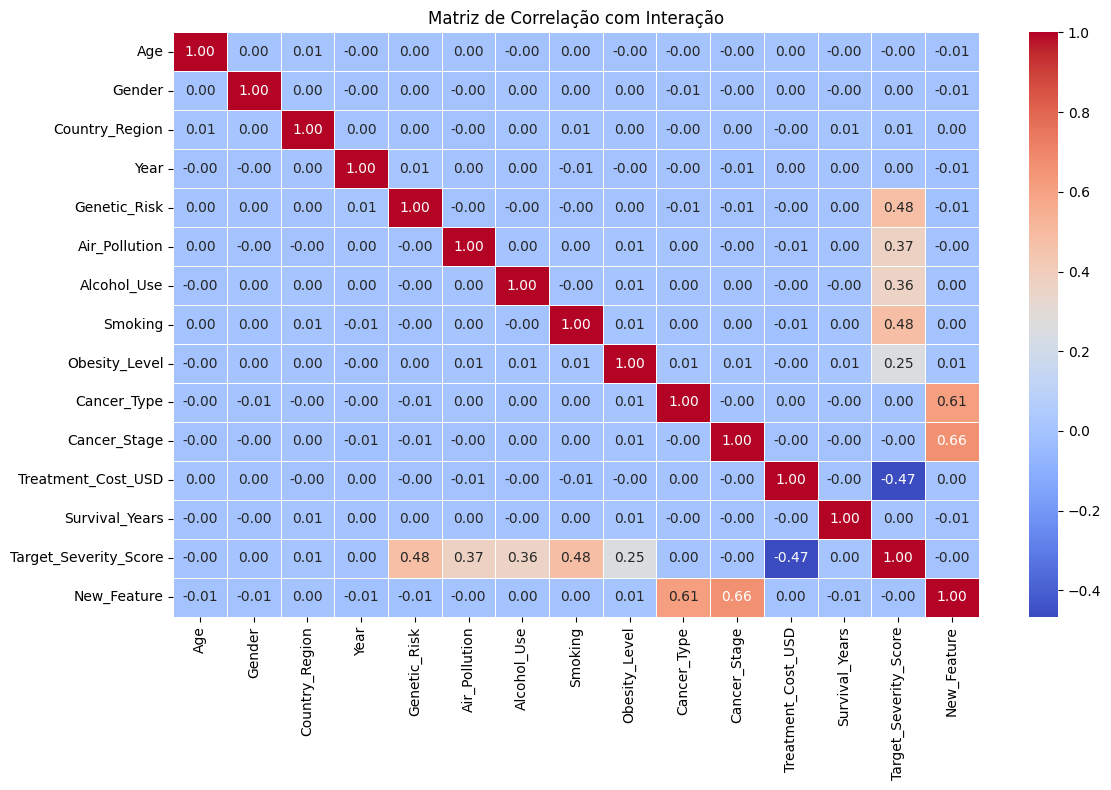

In [ ]:
dados.correlacao_par("Cancer_Type", "Cancer_Stage")

# Modelos

Abaixo entraremos nos modelos utilizados e nos resultados obtidos com cada um, além dos hiperparametros e método de codificação de alguns atributos.

## MLP

O MLP (Perceptron Multi-Camadas) é uma das arquiteturas clássicas de redes neurais artificiais e pertence à categoria dos modelos de aprendizado supervisionado. Ele é composto por, no mínimo, três camadas: uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Cada neurônio em uma camada é totalmente conectado aos neurônios da camada seguinte, sendo essas conexões ponderadas e ajustadas durante o treinamento por meio de algoritmos como o backpropagation.

O MLP é capaz de modelar relações não lineares complexas e, por isso, é utilizado em uma ampla variedade de tarefas, como:

    Regressão (previsão de valores contínuos),

    Classificação (atribuição de rótulos a dados),

    Reconhecimento de padrões,

    Previsão de séries temporais.

Por ser um modelo flexível e relativamente simples, é uma boa escolha para problemas em que os dados têm estrutura não linear mas não necessariamente exigem arquiteturas mais complexas como redes convolucionais ou recorrentes.

In [ ]:
modelo = Modelo()

### Melhor Configuração

Abaixo utilizamos o método check_best_hiperparameter("MLP") para conferir qual configuração entre algumas opções predefinidas apresenta a melhor performance preditiva.

A configuração ideal obtida foi:
hidden_layer_sizes=(100,), activation='identity', alpha=0.001, learning_rate_init=0.001, max_iter=1000, random_state=42

Esses hiperparâmetros indicam que:

    O problema possui características mais lineares, justificando o uso da função de ativação identity (linear).

    A arquitetura da rede, com uma única camada oculta de 100 neurônios, mostra-se suficiente para capturar os padrões relevantes do problema.

    A regularização leve (alpha = 0.001) foi eficaz para evitar overfitting, contribuindo para uma boa capacidade de generalização.

    A taxa de aprendizado padrão (learning_rate_init = 0.001) permitiu uma convergência estável e eficaz durante o treinamento.

Essas escolhas indicam que o problema analisado provavelmente tem uma estrutura bem definida e linear, com um bom volume de dados, permitindo o uso de um modelo simples e eficiente.

In [ ]:
modelo.definir_hiperparametros("MLP")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhor R²: 0.999993996014138
Melhores hiperparâmetros: {'model__activation': 'identity', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (100,), 'model__learning_rate_init': 0.001}


### Resultados

O MLP apresentou excelentes resultados de regressão, com:

    Erro médio muito baixo (MSE ≈ 8.8e-06)

    Altíssimo poder explicativo (R² ≈ 0.999994)


In [ ]:
modelo.treinar_modelo("MLP")

MSE por fold: [8.878720340242566e-06, 8.907179219987568e-06, 8.978039333854873e-06, 8.607270747532247e-06, 8.564980023169972e-06]
MSE médio: 8.787237932957446e-06
R² por fold: [0.9999937511973752, 0.999993808532582, 0.9999937617869548, 0.9999941462719993, 0.9999939931014767]
R² médio: 0.9999938921780777


### Testando Encoding de Atributos x Mapeamento Trivial

Utilizamos a classe OneHotEncoder do scikit-learn para codificar alguns atributos que não tinham relação de ordem e a OrdinalEncoder para atributos com relação de ordem, para verificar se obtinhamos uma melhor performance, oque não foi verificado. A diminuição de desempenho pode ser relacionada ao fato da codificação OneHot levar a significante aumento de dimensionalidade do conjunto de dados.

In [ ]:
modelo = Modelo(encoding=True)
modelo.treinar_modelo("MLP")

MSE por fold: [9.796013767073147e-06, 9.681032579079103e-06, 9.550202228923232e-06, 9.251063447972999e-06, 9.115026488562884e-06]
MSE médio: 9.478667702322274e-06
R² por fold: [0.9999931056104715, 0.9999932706195412, 0.9999933642308845, 0.9999937084343308, 0.9999936073360353]
R² médio: 0.9999934112462526


## SVR

O SVR (Support Vector Regressor) é a versão para regressão do modelo de Máquinas de Vetores de Suporte (SVM - Support Vector Machine). Ao invés de buscar uma fronteira entre classes (como no SVM de classificação), o SVR procura ajustar uma função que se mantenha o mais próxima possível dos dados de treinamento, mas com tolerância a pequenos desvios definidos por um parâmetro ε (epsilon).

A ideia central é:

    Encontrar uma função (geralmente não linear) que tenha erro máximo ε em relação às amostras de treino.

    Penalizar apenas os pontos que ultrapassam esse limite (chamados de vetores de suporte).

In [ ]:
modelo = Modelo()

### Melhor Configuração

Esses hiperparâmetros revelam que o SVR foi configurado para ser:

    Simples e generalizável (C = 0.1, kernel = 'linear');

    Preciso, mas com controle de ruído (epsilon = 0.01);

    Automático e adaptado ao conjunto de dados (gamma = 'scale').

Essa configuração é ideal para problemas com estrutura linear, dados de boa qualidade e demanda por previsões precisas, sem a complexidade ou custo computacional de kernels não lineares.

**A célula abaixo demora para rodar, mais de uma hora na última vez que nos rodamos**

In [ ]:
modelo.definir_hiperparametros("SVR")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhor R²: 0.9999910309630451
Melhores hiperparâmetros: {'model__C': 0.1, 'model__epsilon': 0.01, 'model__kernel': 'linear'}


### Resultados

O SVR apresentou ótimos resultados de regressão, com:

    Erro médio muito baixo (MSE ≈ 1e-05)

    Altíssimo poder explicativo (R² ≈ 0.99999)

Isso mostra que o SVR foi capaz de ajustar bem os dados com alta precisão, mantendo consistência em todas as divisões de validação cruzada. Apesar de, em muitos casos, redes neurais como o MLP serem mais flexíveis, o SVR demonstrou ser altamente eficaz neste problema específico, provavelmente por conta de dados bem distribuídos e dimensionalidade adequada.

In [ ]:
modelo.treinar_modelo("SVR")

MSE por fold: [1.2903980666565096e-05, 1.3188102601759941e-05, 1.2783503820247382e-05, 1.3343428535254023e-05, 1.2963766286514439e-05]
MSE médio: 1.3036556382068176e-05
R² por fold: [0.9999909182376323, 0.9999908328208575, 0.9999911176352285, 0.9999909252533663, 0.9999909080898787]
R² médio: 0.9999909404073927


### Testando Encoding de Atributos x Mapeamento Trivial

Utilizamos a classe OneHotEncoder do scikit-learn para codificar alguns atributos que não tinham relação de ordem e a OrdinalEncoder para atributos com relação de ordem, para verificar se obtinhamos uma melhor performance, oque não foi verificado. A diminuição de desempenho pode ser relacionada ao fato da codificação OneHot levar a significante aumento de dimensionalidade do conjunto de dados.

In [ ]:
modelo = Modelo(encoding=True)
modelo.treinar_modelo("SVR")

MSE por fold: [1.3285712367837913e-05, 1.3439383849534919e-05, 1.3412577704257304e-05, 1.3255798457049441e-05, 1.3144004751937349e-05]
MSE médio: 1.3307495426123384e-05
R² por fold: [0.999990649576613, 0.9999906581528039, 0.9999906805356833, 0.9999909848498003, 0.9999907816827921]
R² médio: 0.9999907509595385


## DTR

O Decision Tree Regressor (Árvore de Decisão para Regressão) é um método de aprendizado supervisionado que divide os dados em regiões menores baseando-se em decisões sequenciais. A cada divisão (ou "nó"), o algoritmo escolhe a variável e o ponto de corte que minimizam o erro de predição nos subconjuntos resultantes.

A árvore constrói essas divisões de forma hierárquica, criando um modelo interpretável que toma decisões semelhantes a um conjunto de regras "se-então".

In [ ]:
modelo = Modelo()

### Melhor Configuração

Esses hiperparâmetros indicam uma árvore com:

    Alta flexibilidade (max_depth = None);

    Critério de divisão eficiente e menos propenso a overfitting (friedman_mse);

    Controle de generalização (min_samples_leaf = 4).

Apesar desses ajustes, os resultados do modelo mostram que a árvore ainda não alcançou a precisão de modelos como SVR e MLP, o que é esperado para árvores isoladas.

In [ ]:
modelo.definir_hiperparametros("DTR")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Melhor R²: 0.9190683466681125
Melhores hiperparâmetros: {'model__criterion': 'friedman_mse', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}


### Resultados

Embora o Decision Tree Regressor apresente uma performance razoável (com R² > 0.91), seus resultados são visivelmente inferiores aos de modelos mais sofisticados como MLP e SVR:

    MSE elevado indica maiores erros de predição.

    R² menor sugere capacidade reduzida de modelar padrões complexos.

Esse desempenho pode ser adequado em cenários onde:

    A interpretação do modelo é prioridade.

    Os dados são mais simples ou menos sensíveis a erros.

In [ ]:
modelo.treinar_modelo("DTR")

### Testando Encoding de Atributos x Mapeamento Trivial

Para árvores de decisão encoding não é necessário, então foi apenas feito o mapeamento padrão de valores diferentes e finitos para inteiros diferentes.

# Conclusões

Neste projeto, foram avaliados diferentes modelos de aprendizado de máquina para resolver um problema de regressão, incluindo MLP (Multi-Layer Perceptron), Decision Tree Regressor e SVR (Support Vector Regressor). Após a realização de experimentos com validação cruzada e ajuste de hiperparâmetros, o modelo que apresentou melhor desempenho foi o MLP, alcançando um R² de 0.999994, o que indica altíssima capacidade preditiva.

A melhor configuração obtida para o MLP foi:

{'model__activation': 'identity', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (100,), 'model__learning_rate_init': 0.001}

Essa configuração revela que:

    O uso da função de ativação identity indica que o problema tem uma estrutura linear, tornando desnecessárias transformações não lineares.

    A arquitetura com uma única camada oculta de 100 neurônios foi suficiente para capturar os padrões dos dados com simplicidade e eficiência.

    A regularização leve (alpha = 0.001) ajudou a evitar sobreajuste, favorecendo a capacidade de generalização do modelo.

    A taxa de aprendizado padrão (learning_rate_init = 0.001) proporcionou uma convergência estável durante o treinamento.

Vale ressaltar que o desempenho do SVR também foi excelente, com um R² de 0.999991.

A melhor configuração obtida para o SVR foi:

{'model__C': 0.1, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Essa configuração revela que:

    O problema apresenta uma relação aproximadamente linear, justificando o uso do kernel linear.

    Um valor pequeno de C e epsilon permitiu controle sobre o ajuste, promovendo regularização e alta precisão, sem sobreajustar os dados.

    O uso de gamma='scale' garantiu uma adaptação adequada à variabilidade dos dados.

Em comparação com os outros modelos e configurações de hiperparametros testados, o MLP com função de ativação indentidade e o SVR com kernel linear se destacaram por sua simplicidade e alta capacidade de predição para um porblema com estrutura linear.